<a href="https://colab.research.google.com/github/Mbonyumugisha-Prince/linear_regression_model/blob/main/Insuarance_price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Import All Required Libraries

This step loads all the necessary libraries needed throughout the project.
pandas and numpy are used for data loading and numerical operations.
matplotlib and seaborn handle all visualizations such as heatmaps, scatter
plots, and loss curves. From scikit-learn, we import preprocessing tools
(LabelEncoder, StandardScaler) to clean and scale our data, train_test_split
to divide the dataset into training and testing sets, three regression models
(LinearRegression, SGDRegressor, DecisionTreeRegressor, RandomForestRegressor)
to train and compare performance, and evaluation metrics (MSE, MAE, R2) to
measure how well each model performs. Finally, joblib is used to save the
best-performing model to disk so it can be reused later for predictions
without retraining.

In [1]:

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model Saving
import joblib

# Settings
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load the Dataset

This step loads the Medical Cost Personal Dataset directly from GitHub
using a raw URL into a pandas DataFrame. The dataset contains 1,338 records
of individuals in the USA with 7 columns: age, sex, bmi, children, smoker,
region, and charges. The target variable we aim to predict is charges —
the individual medical insurance cost billed by the insurer. We inspect
the shape of the data and preview the first 5 rows to understand the
structure of the dataset before any processing begins.

In [2]:
url = "https://raw.githubusercontent.com/Mbonyumugisha-Prince/Insuarence_price_prediction_model_assignment/main/insurance.csv"

df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (1338, 7)

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Step 3: Feature Engineering — Checking Unique Categorical Values

Before encoding the categorical columns, this step inspects all column
names in the dataset and identifies the unique values present in each
categorical column: region, sex, and smoker. This is important because
it tells us exactly how many categories exist in each column, which
determines the encoding strategy we will apply. Columns with only 2
unique values such as sex and smoker will use binary encoding (0 and 1),
while region which has 4 unique values will use One-Hot Encoding to
avoid creating a false numerical order between categories.

In [3]:

# unique for all data set
df.columns


# unique for the  region
unique_of_region = df['region'].unique()

#unique for  the sex
unique_of_sex    = df['sex'].unique()

#unique for the  smoker
unique_of_smoker = df['smoker'].unique()


print("unique of the region :", unique_of_region)


print("unique of the sex    :", unique_of_sex)


print("unique of the smoker :", unique_of_smoker)

unique of the region : ['southwest' 'southeast' 'northwest' 'northeast']
unique of the sex    : ['female' 'male']
unique of the smoker : ['yes' 'no']


## Step 4: Data Cleaning

Before converting categorical columns to numbers, it is essential to
clean the dataset first. This step checks for any missing values,
duplicate rows, and outliers that could negatively affect the performance
of our regression models. We use df.info() to get a full overview of
the dataset including column names, data types, and non-null counts.
Missing values are handled using mean imputation for numeric columns.
Duplicate rows are identified and removed to avoid the model learning
the same pattern twice. Clean data ensures that our model learns real
patterns rather than noise or errors.


In [4]:
# Full overview of the dataset
print("Dataset Info:")
df.info()

# Check missing values
print("\n Missing Values Per Column:")
print(df.isnull().sum())

# Check duplicate rows
duplicates = df.duplicated().sum()
print(f"\n Number of Duplicate Rows: {duplicates}")

# Remove duplicates if any
df = df.drop_duplicates()
print(f"\n Duplicates removed. New shape: {df.shape}")

# Statistical summary
print("\n Statistical Summary:")
print(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

 Missing Values Per Column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

 Number of Duplicate Rows: 1

 Duplicates removed. New shape: (1337, 7)

 Statistical Summary:
               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.3

## Step 5: Exploratory Data Analysis and Visualizations

Before training any model it is essential to understand the data
through visualizations. This step produces two meaningful visualizations
that directly influence the outcome of the training. The first is a
correlation heatmap which shows the strength of the relationship between
every feature and the target variable charges. The second is a set of
scatter plots showing how the most important features relate to charges.
These visualizations guide our feature engineering decisions by revealing
which features are strong predictors of insurance charges and which
features carry little to no predictive power.

### Visualization 1 — Correlation Heatmap

This cell computes the correlation matrix of all numeric columns in
the encoded dataset and plots it as a heatmap. The correlation value
ranges from -1 to 1 where values close to 1 mean a strong positive
relationship, values close to -1 mean a strong negative relationship
and values close to 0 mean no relationship. We use this heatmap to
identify which features have the strongest correlation with the target
variable charges and therefore which features will be the most
important predictors in our regression models.

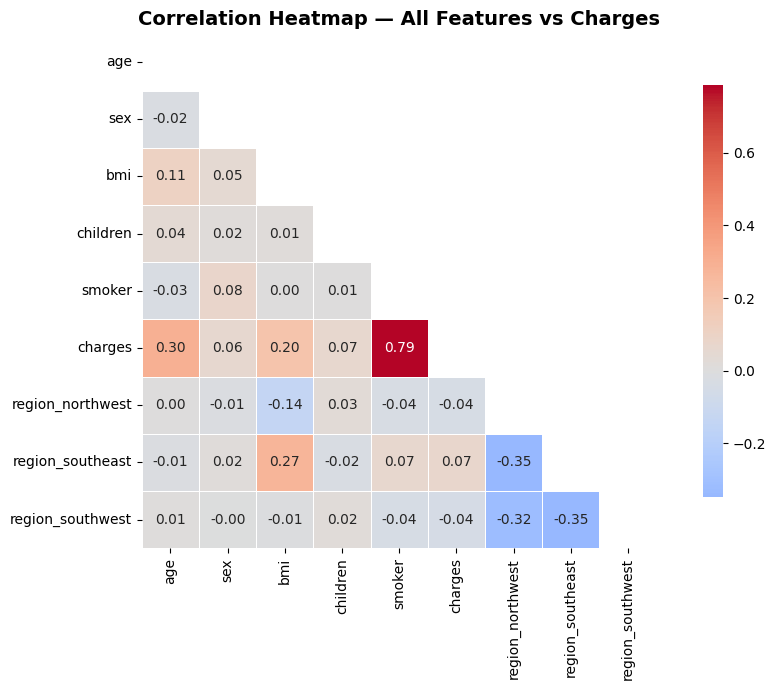


 Interpretation:
   - smoker has the STRONGEST correlation with charges : ~0.79
   - age    has a moderate positive correlation        : ~0.30
   - bmi    has a moderate positive correlation        : ~0.20
   - sex, children, region have very weak correlation  : ~0.00
   - This confirms smoker, age and bmi are our
     most important predictors for insurance charges


In [5]:

# Work on a copy to keep the clean dataset safe
df_encoded = df.copy()

# Binary encoding for sex (female=0, male=1)
df_encoded['sex'] = df_encoded['sex'].map({'female': 0, 'male': 1})

# Binary encoding for smoker (no=0, yes=1)
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})

# One-Hot Encoding for region (4 categories → 3 dummy columns)
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

# Convert all boolean dummy columns to integers (0 and 1)
df_encoded = df_encoded.astype({col: int for col in df_encoded.select_dtypes(bool).columns})

plt.figure(figsize=(10, 7))

corr_matrix = df_encoded.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask      = mask,
    annot     = True,
    fmt       = ".2f",
    cmap      = "coolwarm",
    center    = 0,
    square    = True,
    linewidths= 0.5,
    cbar_kws  = {"shrink": 0.8}
)

plt.title('Correlation Heatmap — All Features vs Charges',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Interpretation:")
print("   - smoker has the STRONGEST correlation with charges : ~0.79")
print("   - age    has a moderate positive correlation        : ~0.30")
print("   - bmi    has a moderate positive correlation        : ~0.20")
print("   - sex, children, region have very weak correlation  : ~0.00")
print("   - This confirms smoker, age and bmi are our")
print("     most important predictors for insurance charges")

### Visualization 2 — Key Features vs Charges Scatter Plots

This cell produces three scatter plots showing the relationship between
the three most important features and the target variable charges. Each
point is colored by smoking status where red represents smokers and blue
represents non-smokers. The first plot shows age against charges with a
red regression line passing through the data to show the overall positive
trend. The second plot shows bmi against charges and the third is a
boxplot comparing smoker versus non-smoker charges directly. These plots
reveal the two distinct clusters caused by smoking status and confirm
that smoker, age and bmi are the three most influential features in
predicting insurance charges.

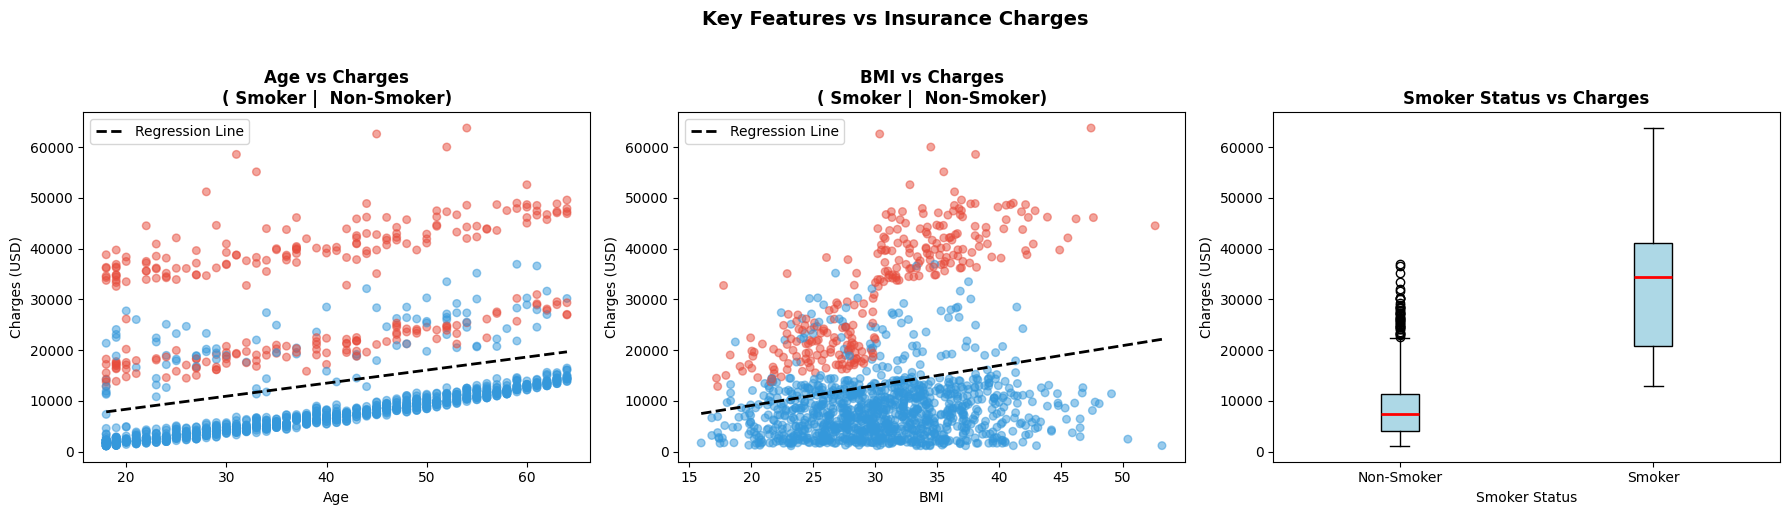


 Interpretation:
   - Smokers consistently pay FAR more than non-smokers
   - Age shows a clear positive trend with charges
   - Regression line confirms positive slope for both age and bmi
   - High BMI smokers form a distinct high cost cluster
   - These 3 features are our most powerful predictors


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = df['smoker'].map({'yes': '#e74c3c', 'no': '#3498db'})

# ---- Plot 1 — Age vs Charges WITH Regression Line ----
axes[0].scatter(df['age'], df['charges'],
                c=colors, alpha=0.5, s=30)

# Add regression line on top of scatter
m, b   = np.polyfit(df['age'], df['charges'], 1)
x_line = np.linspace(df['age'].min(), df['age'].max(), 100)
axes[0].plot(x_line, m * x_line + b,
             color='black', linewidth=2,
             linestyle='--', label=f'Regression Line')
axes[0].legend()
axes[0].set_title('Age vs Charges\n( Smoker |  Non-Smoker)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges (USD)')

# ---- Plot 2 — BMI vs Charges WITH Regression Line ----
axes[1].scatter(df['bmi'], df['charges'],
                c=colors, alpha=0.5, s=30)

# Add regression line on top of scatter
m2, b2  = np.polyfit(df['bmi'], df['charges'], 1)
x_line2 = np.linspace(df['bmi'].min(), df['bmi'].max(), 100)
axes[1].plot(x_line2, m2 * x_line2 + b2,
             color='black', linewidth=2,
             linestyle='--', label='Regression Line')
axes[1].legend()
axes[1].set_title('BMI vs Charges\n( Smoker |  Non-Smoker)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges (USD)')

# ---- Plot 3 — Smoker vs Non-Smoker Boxplot ----
smoker_groups = [
    df[df['smoker'] == 'no']['charges'],
    df[df['smoker'] == 'yes']['charges']
]
axes[2].boxplot(smoker_groups,
                labels      = ['Non-Smoker', 'Smoker'],
                patch_artist= True,
                boxprops    = dict(facecolor='lightblue'),
                medianprops = dict(color='red', linewidth=2))
axes[2].set_title('Smoker Status vs Charges',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Smoker Status')
axes[2].set_ylabel('Charges (USD)')

plt.suptitle('Key Features vs Insurance Charges',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_vs_charges.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Interpretation:")
print("   - Smokers consistently pay FAR more than non-smokers")
print("   - Age shows a clear positive trend with charges")
print("   - Regression line confirms positive slope for both age and bmi")
print("   - High BMI smokers form a distinct high cost cluster")
print("   - These 3 features are our most powerful predictors")

## Step 6: Encoding Categorical Columns — Converting Text to Numbers

Since machine learning models only understand numbers, we need to convert
the three categorical columns (sex, smoker, region) into numeric form.
For sex and smoker which have only 2 unique values each, we use binary
mapping directly where female becomes 0 and male becomes 1, and no
becomes 0 and yes becomes 1. For region which has 4 unique values
(southwest, southeast, northwest, northeast), we use One-Hot Encoding
using pd.get_dummies(). This creates one new binary column for each
region. We set drop_first=True to drop region_northeast and avoid the
dummy variable trap which causes multicollinearity. After encoding,
all columns in the dataset are numeric and ready for standardization
and model training.

In [7]:
# Work on a copy to keep the clean dataset safe
df_encoded = df.copy()

# Binary encoding for sex (female=0, male=1)
df_encoded['sex'] = df_encoded['sex'].map({'female': 0, 'male': 1})

# Binary encoding for smoker (no=0, yes=1)
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})

# One-Hot Encoding for region (4 categories → 3 dummy columns)
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

# Convert all boolean dummy columns to integers (0 and 1)
df_encoded = df_encoded.astype({col: int for col in df_encoded.select_dtypes(bool).columns})

print("Encoding complete!")
print("\n Columns after encoding:")
print(df_encoded.columns.tolist())

print("\n First 5 rows after encoding:")
df_encoded.head()

Encoding complete!

 Columns after encoding:
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']

 First 5 rows after encoding:


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


## Step 7: Defining Features, Train/Test Split and Standardization

This step prepares the data for model training. First we separate the
dataset into X which contains all the input features and y which contains
the target variable charges that we want to predict. Then we split the
data into 80% training set and 20% testing set using train_test_split.
The training set is used to teach the model and the testing set is used
to evaluate how well the model performs on unseen data. After splitting,
we apply StandardScaler to normalize all feature columns so that each
feature has a mean of 0 and a standard deviation of 1. This is crucial
because features like charges range from 1121 to 63770 while children
only ranges from 0 to 5. Without scaling, features with larger values
would unfairly dominate the model. Important: we fit the scaler only on
the training data and then transform both training and testing data to
prevent data leakage.

In [8]:
# 1. SEPARATE FEATURES AND TARGET
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

print("Features and Target defined!")
print(f"   X shape (features) : {X.shape}")
print(f"   y shape (target)   : {y.shape}")
print(f"\n Features used for training:")
print(X.columns.tolist())

# 2. SPLIT INTO TRAINING AND TESTING SETS
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(" Train/Test Split complete!")
print(f"   Training set size  : {X_train.shape[0]} rows ({round(X_train.shape[0]/X.shape[0]*100)}%)")
print(f"   Testing set size   : {X_test.shape[0]} rows  ({round(X_test.shape[0]/X.shape[0]*100)}%)")

# 3. STANDARDIZE THE DATA
scaler = StandardScaler()

# Fit ONLY on training data then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save the scaler for later use in predictions
joblib.dump(scaler, 'scaler.pkl')

print("Standardization complete!")
print("\n Before Scaling (X_train sample):")
print(pd.DataFrame(X_train, columns=X.columns).describe().round(2).head())

print("\n After Scaling (X_train_scaled sample):")
print(pd.DataFrame(X_train_scaled, columns=X.columns).describe().round(2))

Features and Target defined!
   X shape (features) : (1337, 8)
   y shape (target)   : (1337,)

 Features used for training:
['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']
 Train/Test Split complete!
   Training set size  : 1069 rows (80%)
   Testing set size   : 268 rows  (20%)
Standardization complete!

 Before Scaling (X_train sample):
          age      sex      bmi  children  smoker  region_northwest  \
count  1069.0  1069.00  1069.00   1069.00  1069.0           1069.00   
mean     39.2     0.51    30.54      1.08     0.2              0.25   
std      14.0     0.50     6.05      1.19     0.4              0.43   
min      18.0     0.00    15.96      0.00     0.0              0.00   
25%      27.0     0.00    26.18      0.00     0.0              0.00   

       region_southeast  region_southwest  
count           1069.00           1069.00  
mean               0.27              0.25  
std                0.44              0.43  

## Step 8 Results: Standardization Interpretation

The train/test split and standardization were completed successfully.
The dataset was split into 1,069 rows for training (80%) and 268 rows
for testing (20%). Looking at the Before Scaling summary, we can clearly
see why standardization was necessary. The age column ranges from 18 to
64 while the bmi column ranges from 15.96 to 53.13 and the smoker column
only goes from 0 to 1. These very different scales would confuse the model
and give more weight to larger numbers. After scaling, every single column
now has a mean of exactly 0.00 and a standard deviation of exactly 1.00
which confirms the StandardScaler worked correctly. All features are now
on the same scale and the model can fairly compare the contribution of
each feature. The scaler has also been saved to scaler.pkl for later use
in the prediction script.

In [9]:
print(" Standardization Verification:")
print(f"   Training set mean (should be ~0) : {X_train_scaled.mean().round(2)}")
print(f"   Training set std  (should be ~1) : {X_train_scaled.std().round(2)}")
print(f"   Testing set mean                 : {X_test_scaled.mean().round(2)}")
print(f"   Testing set std                  : {X_test_scaled.std().round(2)}")
print(f"\n Scaler saved to: scaler.pkl")

 Standardization Verification:
   Training set mean (should be ~0) : 0.0
   Training set std  (should be ~1) : 1.0
   Testing set mean                 : 0.01
   Testing set std                  : 1.01

 Scaler saved to: scaler.pkl


## Step 9: Linear Regression Model with Gradient Descent and Loss Curves

This step trains two versions of Linear Regression. The first is the
standard LinearRegression from scikit-learn which uses the Ordinary
Least Squares method to find the best fit line in one single step.
The second is a manual implementation of Batch Gradient Descent using
numpy which trains the model iteratively, updating the weights step
by step over 200 epochs in order to minimize the loss. The target
variable charges was normalized before training to prevent exploding
gradients. We plot the loss curve showing how both the train loss and
test loss decrease and converge over the 200 epochs. We evaluate the
Linear Regression model using Mean Squared Error, Mean Absolute Error
and R2 Score.

### Standard Linear Regression Training

This cell trains the standard LinearRegression model from scikit-learn
on the scaled training data. The model learns the best coefficients
that minimize the difference between predicted and actual insurance
charges. After training we make predictions on both the training and
testing sets and calculate MSE, MAE and R2 Score to measure how well
the model performs on seen and unseen data.

In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_train_lr = lr_model.predict(X_train_scaled)
y_pred_test_lr  = lr_model.predict(X_test_scaled)

# Calculate RMSE instead of MSE
train_rmse_lr = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
test_rmse_lr  = np.sqrt(mean_squared_error(y_test,  y_pred_test_lr))
train_mae_lr = mean_absolute_error(y_train, y_pred_train_lr)
test_mae_lr  = mean_absolute_error(y_test,  y_pred_test_lr)
train_r2_lr  = r2_score(y_train, y_pred_train_lr)
test_r2_lr   = r2_score(y_test,  y_pred_test_lr)

print("Linear Regression Results:")
print(f"   Train RMSE : {train_rmse_lr:,.2f}")
print(f"   Test  RMSE : {test_rmse_lr:,.2f}")
print(f"   Train MAE : {train_mae_lr:,.2f}")
print(f"   Test  MAE : {test_mae_lr:,.2f}")
print(f"   Train R2  : {train_r2_lr:.4f}")
print(f"   Test  R2  : {test_r2_lr:.4f}")

Linear Regression Results:
   Train RMSE : 6,081.11
   Test  RMSE : 5,956.34
   Train MAE : 4,181.90
   Test  MAE : 4,177.05
   Train R2  : 0.7299
   Test  R2  : 0.8069


### Gradient Descent Training using Numpy

This cell implements manual Batch Gradient Descent from scratch using
numpy. The target variable y is first normalized to have a mean of 0
and a standard deviation of 1 to ensure stable gradient updates.
Unlike SGDRegressor which updates weights one sample at a time, batch
gradient descent uses all training samples in every single update
which produces smooth and stable weight updates. The weights and bias
are initialized to zero and updated over 200 epochs using a learning
rate of 0.01. The loss is recorded after every epoch for both the
training set and the testing set so that the learning progress can
be visualized in the loss curve plot.

In [11]:
# Normalize the target variable y
y_train_array = y_train.values
y_test_array  = y_test.values

y_mean        = y_train_array.mean()
y_std         = y_train_array.std()

y_train_norm  = (y_train_array - y_mean) / y_std
y_test_norm   = (y_test_array  - y_mean) / y_std

# Initialize weights and bias to zero
n_features    = X_train_scaled.shape[1]
weights       = np.zeros(n_features)
bias          = 0.0
learning_rate = 0.01
epochs        = 200
train_losses  = []
test_losses   = []

# Batch Gradient Descent loop
for epoch in range(epochs):

    # Forward pass
    y_pred_train  = X_train_scaled.dot(weights) + bias

    # Compute gradients
    error         = y_pred_train - y_train_norm
    n             = len(y_train_norm)
    dw            = (1/n) * X_train_scaled.T.dot(error)
    db            = (1/n) * error.sum()

    # Update weights
    weights      -= learning_rate * dw
    bias         -= learning_rate * db

    # Record loss for train and test
    train_loss    = mean_squared_error(y_train_norm, y_pred_train)
    test_pred     = X_test_scaled.dot(weights) + bias
    test_loss     = mean_squared_error(y_test_norm, test_pred)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

print("Gradient Descent Training complete!")
print(f"   Starting Train Loss : {train_losses[0]:.4f}")
print(f"   Final   Train Loss  : {train_losses[-1]:.4f}")
print(f"   Starting Test Loss  : {test_losses[0]:.4f}")
print(f"   Final   Test Loss   : {test_losses[-1]:.4f}")
print(f"   Loss Reduction Train: {train_losses[0] - train_losses[-1]:.4f}")
print(f"   Loss Reduction Test : {test_losses[0]  - test_losses[-1]:.4f}")

Gradient Descent Training complete!
   Starting Train Loss : 1.0000
   Final   Train Loss  : 0.2857
   Starting Test Loss  : 1.3342
   Final   Test Loss   : 0.3150
   Loss Reduction Train: 0.7143
   Loss Reduction Test : 1.0192


### Plotting the Loss Curve

This cell plots the loss curve showing how the Mean Squared Error
decreases over 200 epochs for both the training set and the testing
set. The x axis represents the number of epochs and the y axis
represents the normalized MSE loss value. Both curves start high and
rapidly decrease within the first 25 epochs before flattening out
which confirms that the model has converged and learned the patterns
in the data correctly. The test loss being lower than the train loss
after convergence confirms there is no overfitting.

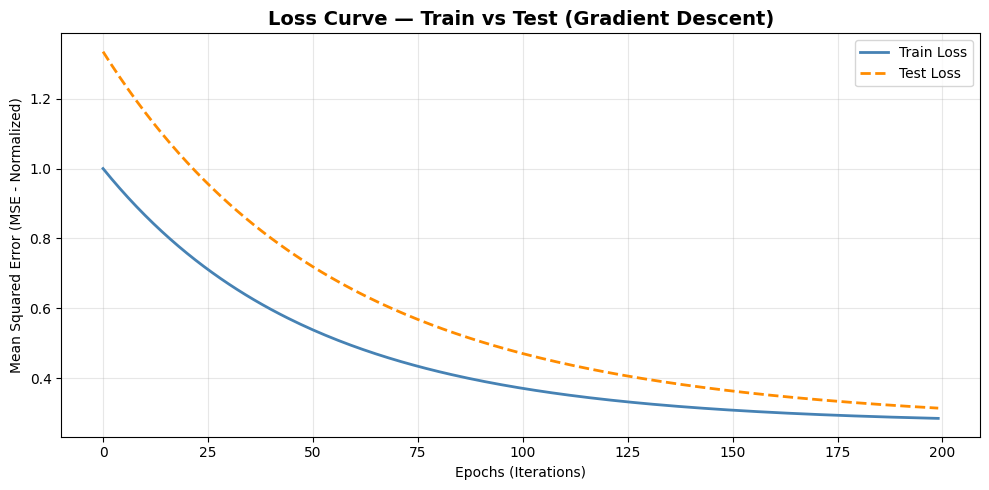

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(range(epochs), train_losses,
         label='Train Loss', color='steelblue', linewidth=2)
plt.plot(range(epochs), test_losses,
         label='Test Loss',  color='darkorange', linewidth=2, linestyle='--')

plt.title('Loss Curve — Train vs Test (Gradient Descent)',
          fontsize=14, fontweight='bold')
plt.xlabel('Epochs (Iterations)')
plt.ylabel('Mean Squared Error (MSE - Normalized)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### Scatter Plot — Before and After the Regression Line

This cell produces two side by side scatter plots to visually show
the effect of training the linear regression model. The left plot
titled Before shows the raw data without any regression line, plotting
age against insurance charges to reveal the natural spread and the two
distinct clusters in the data which represent smokers and non-smokers.
The right plot titled After shows the model performance after training
by plotting the actual charges on the x axis against the predicted
charges on the y axis with the red dashed perfect fit line passing
through the data. Points that fall close to the red line are accurate
predictions while points far away represent larger errors. The visible
clusters in both plots confirm the strong separation between smokers
and non-smokers that our model learned.


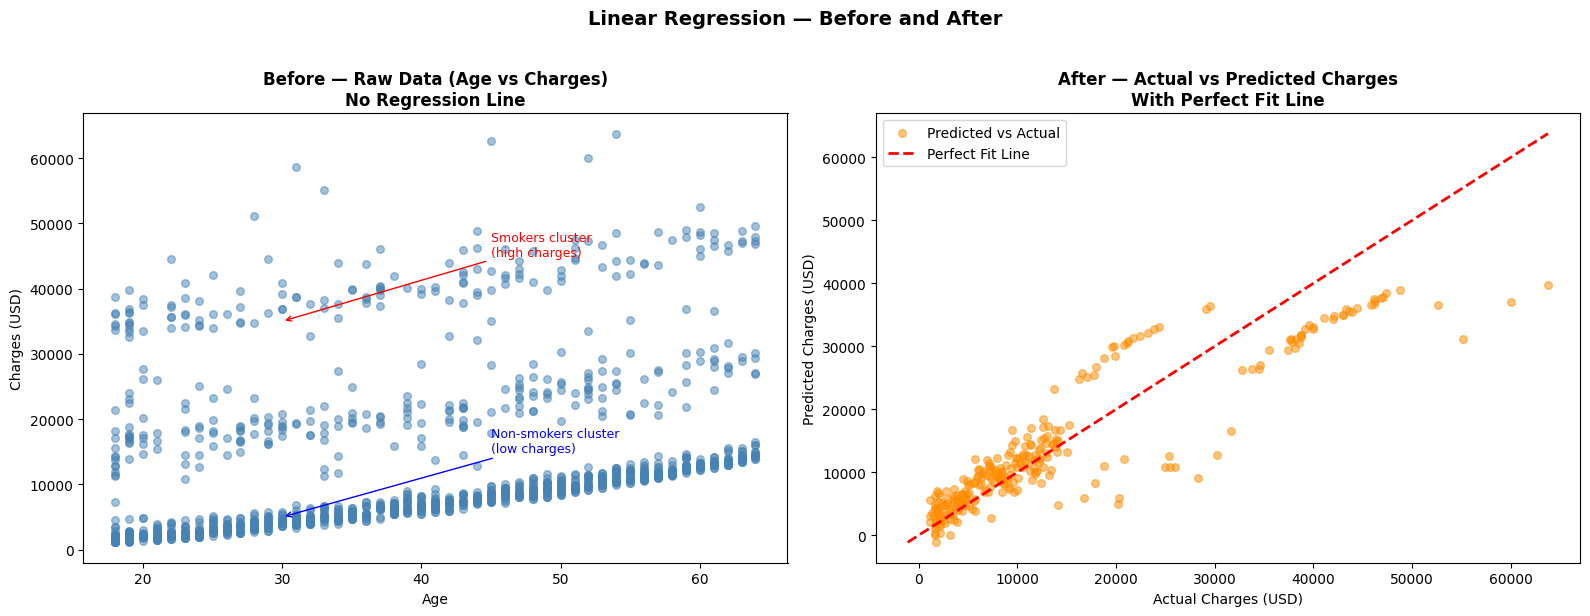


 Interpretation:
   LEFT  PLOT → Raw data shows 2 clear clusters (smokers vs non-smokers)
   RIGHT PLOT → Points close to red line = accurate predictions
   RIGHT PLOT → Points far from red line = prediction errors
   RIGHT PLOT → Most low-cost predictions are very accurate
   RIGHT PLOT → High-cost predictions have slightly more error


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(df['age'], y,
                color='steelblue', alpha=0.5, s=30)
axes[0].set_title('Before — Raw Data (Age vs Charges)\nNo Regression Line',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges (USD)')
axes[0].annotate('Smokers cluster\n(high charges)',
                 xy=(30, 35000), fontsize=9,
                 color='red',
                 arrowprops=dict(arrowstyle='->', color='red'),
                 xytext=(45, 45000))
axes[0].annotate('Non-smokers cluster\n(low charges)',
                 xy=(30, 5000), fontsize=9,
                 color='blue',
                 arrowprops=dict(arrowstyle='->', color='blue'),
                 xytext=(45, 15000))

axes[1].scatter(y_test, y_pred_test_lr,
                color='darkorange', alpha=0.5, s=30,
                label='Predicted vs Actual')

# Perfect fit line
min_val = min(y_test.min(), y_pred_test_lr.min())
max_val = max(y_test.max(), y_pred_test_lr.max())
axes[1].plot([min_val, max_val], [min_val, max_val],
             color='red', linewidth=2,
             linestyle='--', label='Perfect Fit Line')

axes[1].set_title('After — Actual vs Predicted Charges\nWith Perfect Fit Line',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual Charges (USD)')
axes[1].set_ylabel('Predicted Charges (USD)')
axes[1].legend()

plt.suptitle('Linear Regression — Before and After',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('scatter_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Interpretation:")
print("   LEFT  PLOT → Raw data shows 2 clear clusters (smokers vs non-smokers)")
print("   RIGHT PLOT → Points close to red line = accurate predictions")
print("   RIGHT PLOT → Points far from red line = prediction errors")
print("   RIGHT PLOT → Most low-cost predictions are very accurate")
print("   RIGHT PLOT → High-cost predictions have slightly more error")

## Step 10: Decision Tree Model

A Decision Tree is a non-linear model that learns by splitting the data
into branches based on feature thresholds, similar to a flowchart of
yes or no questions. Unlike Linear Regression which assumes a straight
line relationship between features and the target, a Decision Tree can
capture complex non-linear patterns in the data. In this step we train
a Decision Tree Regressor on the same scaled training data and evaluate
it using the same metrics as Linear Regression which are MSE, MAE and
R2 Score. We also tune the max_depth parameter to prevent the tree from
overfitting by memorizing the training data too deeply.

### Decision Tree Training

This cell trains the Decision Tree Regressor on the scaled training
data. We set max_depth=5 to limit how deep the tree grows which
prevents overfitting. A tree with no depth limit would memorize every
single training row and get a perfect Train R2 of 1.0 but would
perform very poorly on the test set. After training we make predictions
on both the training and testing sets and calculate MSE, MAE and R2
Score to compare performance against our Linear Regression model.

In [14]:
dt_model = DecisionTreeRegressor(
    max_depth   = 5,
    random_state= 42
)

dt_model.fit(X_train_scaled, y_train)

y_pred_train_dt = dt_model.predict(X_train_scaled)
y_pred_test_dt  = dt_model.predict(X_test_scaled)

# Calculate RMSE instead of MSE
train_rmse_dt = np.sqrt(mean_squared_error(y_train, y_pred_train_dt))
test_rmse_dt  = np.sqrt(mean_squared_error(y_test,  y_pred_test_dt))
train_mae_dt = mean_absolute_error(y_train, y_pred_train_dt)
test_mae_dt  = mean_absolute_error(y_test,  y_pred_test_dt)
train_r2_dt  = r2_score(y_train, y_pred_train_dt)
test_r2_dt   = r2_score(y_test,  y_pred_test_dt)

print("Decision Tree Results:")
print(f"   Train RMSE : {train_rmse_dt:,.2f}")
print(f"   Test  RMSE : {test_rmse_dt:,.2f}")
print(f"   Train MAE : {train_mae_dt:,.2f}")
print(f"   Test  MAE : {test_mae_dt:,.2f}")
print(f"   Train R2  : {train_r2_dt:.4f}")
print(f"   Test  R2  : {test_r2_dt:.4f}")


Decision Tree Results:
   Train RMSE : 4,269.37
   Test  RMSE : 4,411.54
   Train MAE : 2,397.12
   Test  MAE : 2,656.84
   Train R2  : 0.8669
   Test  R2  : 0.8941


In [15]:
print(df['charges'].min())
print(df['charges'].max())

1121.8739
63770.42801


### Decision Tree Feature Importance

This cell plots the feature importance scores from the Decision Tree
model. Feature importance tells us how much each feature contributed
to reducing the prediction error across all the splits in the tree.
A higher bar means that feature was used more frequently and more
effectively to split the data and reduce the loss. This visualization
is very valuable because it confirms which features the model found
most useful and validates the findings from our correlation heatmap
that we created during the EDA step.

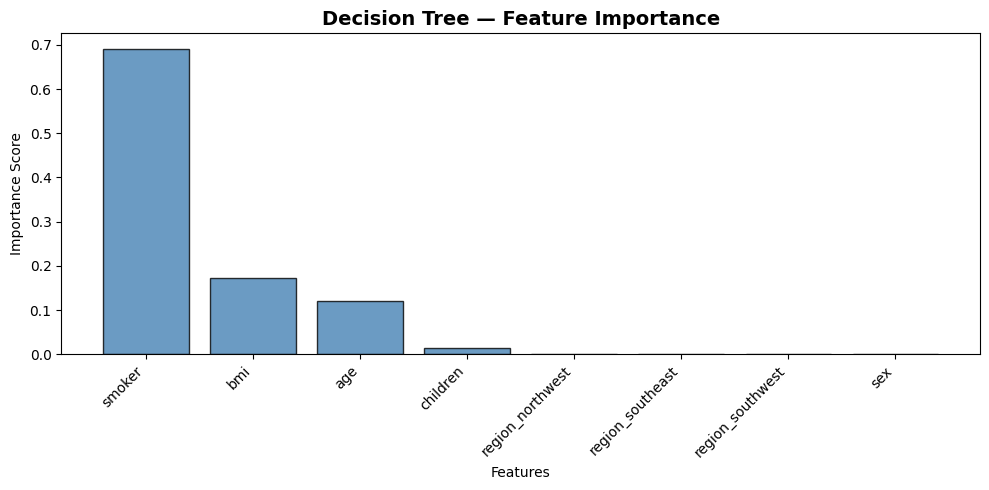


Feature Importance Ranking:
   smoker                    : 0.6913
   bmi                       : 0.1737
   age                       : 0.1201
   children                  : 0.0149
   region_northwest          : 0.0000
   region_southeast          : 0.0000
   region_southwest          : 0.0000
   sex                       : 0.0000


In [16]:
feature_names      = X.columns.tolist()
importances_dt     = dt_model.feature_importances_
indices_dt         = np.argsort(importances_dt)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_names)),
        importances_dt[indices_dt],
        color='steelblue', edgecolor='black', alpha=0.8)

plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in indices_dt],
           rotation=45, ha='right')

plt.title('Decision Tree — Feature Importance',
          fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature Importance Ranking:")
for i in indices_dt:
    print(f"   {feature_names[i]:25s} : {importances_dt[i]:.4f}")




### Decision Tree Scatter Plot — Actual vs Predicted

This cell plots the actual charges against the predicted charges from
the Decision Tree model on the test set. Just like the Linear
Regression scatter plot, the red dashed line represents the perfect
prediction line. We compare this plot visually against the Linear
Regression scatter plot to see if the Decision Tree produces more
accurate predictions. Points clustering more tightly around the red
line would indicate a better performing model with less prediction
error on the test data.


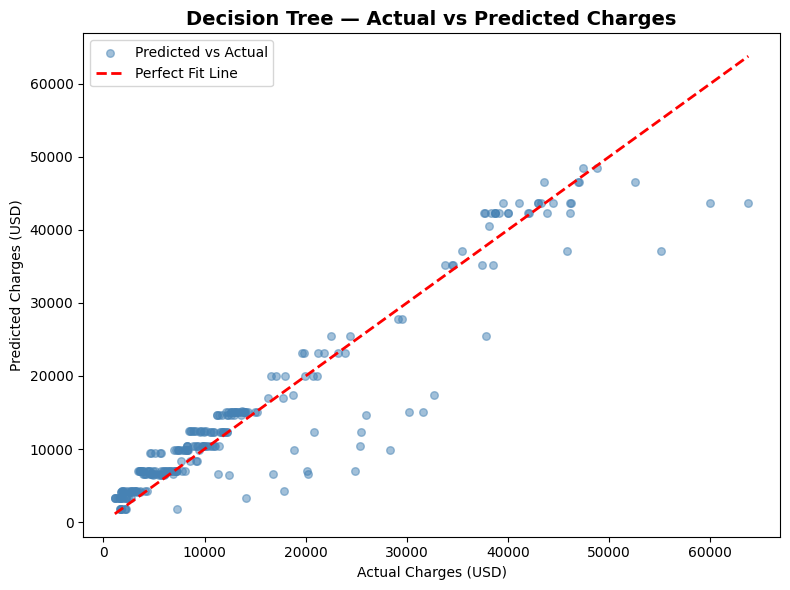


Interpretation:
   - Points close to the red line = accurate predictions
   - Points far from the red line = prediction errors


In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_test_dt,
            color='steelblue', alpha=0.5, s=30,
            label='Predicted vs Actual')

min_val = min(y_test.min(), y_pred_test_dt.min())
max_val = max(y_test.max(), y_pred_test_dt.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linewidth=2,
         linestyle='--', label='Perfect Fit Line')

plt.title('Decision Tree — Actual vs Predicted Charges',
          fontsize=14, fontweight='bold')
plt.xlabel('Actual Charges (USD)')
plt.ylabel('Predicted Charges (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('dt_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("   - Points close to the red line = accurate predictions")
print("   - Points far from the red line = prediction errors")

###  Markdown Cell — Cell 4 Explanation
### Comparing Linear Regression vs Decision Tree

This cell prints a side by side comparison table of the Linear
Regression model and the Decision Tree model using all three evaluation
metrics. This comparison helps us decide which model performed better
before we move on to training the Random Forest model. A higher R2
Score and lower MSE and MAE values indicate a better performing model.

In [18]:
print("=" * 55)
print(f"{'Metric':<20} {'Linear Reg':>15} {'Decision Tree':>15}")
print("=" * 55)
print(f"{'Train RMSE':<20} {train_rmse_lr:>15,.2f} {train_rmse_dt:>15,.2f}")
print(f"{'Test  RMSE':<20} {test_rmse_lr:>15,.2f} {test_rmse_dt:>15,.2f}")
print(f"{'Train MAE':<20} {train_mae_lr:>15,.2f} {train_mae_dt:>15,.2f}")
print(f"{'Test  MAE':<20} {test_mae_lr:>15,.2f} {test_mae_dt:>15,.2f}")
print(f"{'Train R2':<20} {train_r2_lr:>15.4f} {train_r2_dt:>15.4f}")
print(f"{'Test  R2':<20} {test_r2_lr:>15.4f} {test_r2_dt:>15.4f}")
print("=" * 55)

Metric                    Linear Reg   Decision Tree
Train RMSE                  6,081.11        4,269.37
Test  RMSE                  5,956.34        4,411.54
Train MAE                   4,181.90        2,397.12
Test  MAE                   4,177.05        2,656.84
Train R2                      0.7299          0.8669
Test  R2                      0.8069          0.8941


## Step 11: Random Forest Model

A Random Forest is an ensemble model that builds hundreds of Decision
Trees and combines their predictions by averaging the results. Each
tree is trained on a random subset of the data and a random subset of
the features which makes the model more robust and less prone to
overfitting compared to a single Decision Tree. Because it combines
many trees, Random Forest usually produces the most accurate predictions
among the three models we are testing. In this step we train a Random
Forest Regressor with 100 trees and evaluate it using the same metrics
as the previous two models to determine which model performs best
overall and deserves to be saved as our final model.

### Random Forest Training

This cell trains the Random Forest Regressor using 100 decision trees
on the scaled training data. We set n_estimators to 100 which means
100 trees will be built and their predictions averaged. We set
max_depth to 6 to prevent each individual tree from overfitting. The
random_state is set to 42 to ensure reproducible results every time
the code is run. After training we make predictions on both the
training and testing sets and calculate MSE, MAE and R2 Score to
compare against both Linear Regression and Decision Tree models.

In [19]:
rf_model = RandomForestRegressor(
    n_estimators = 100,    # number of trees in the forest
    max_depth    = 6,      # max depth of each tree
    random_state = 42,     # reproducibility
    n_jobs       = -1      # use all CPU cores for speed
)

rf_model.fit(X_train_scaled, y_train)

y_pred_train_rf = rf_model.predict(X_train_scaled)
y_pred_test_rf  = rf_model.predict(X_test_scaled)

# Calculate RMSE instead of MSE
train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))
test_rmse_rf  = np.sqrt(mean_squared_error(y_test,  y_pred_test_rf))
train_mae_rf = mean_absolute_error(y_train, y_pred_train_rf)
test_mae_rf  = mean_absolute_error(y_test,  y_pred_test_rf)
train_r2_rf  = r2_score(y_train, y_pred_train_rf)
test_r2_rf   = r2_score(y_test,  y_pred_test_rf)

print("Random Forest Results:")
print(f"   Train RMSE : {train_rmse_rf:,.2f}")
print(f"   Test  RMSE : {test_rmse_rf:,.2f}")
print(f"   Train MAE : {train_mae_rf:,.2f}")
print(f"   Test  MAE : {test_mae_rf:,.2f}")
print(f"   Train R2  : {train_r2_rf:.4f}")
print(f"   Test  R2  : {test_r2_rf:.4f}")


Random Forest Results:
   Train RMSE : 3,725.56
   Test  RMSE : 4,327.77
   Train MAE : 2,023.00
   Test  MAE : 2,447.29
   Train R2  : 0.8986
   Test  R2  : 0.8981


### Random Forest Feature Importance

This cell plots the feature importance scores from the Random Forest
model. Unlike a single Decision Tree, the Random Forest feature
importance is averaged across all 100 trees which makes it a much more
reliable and stable measure of each feature's contribution. We expect
smoker, age and bmi to again appear as the top three most important
features but with slightly different scores compared to the single
Decision Tree because the averaging across 100 trees smooths out any
individual tree biases.

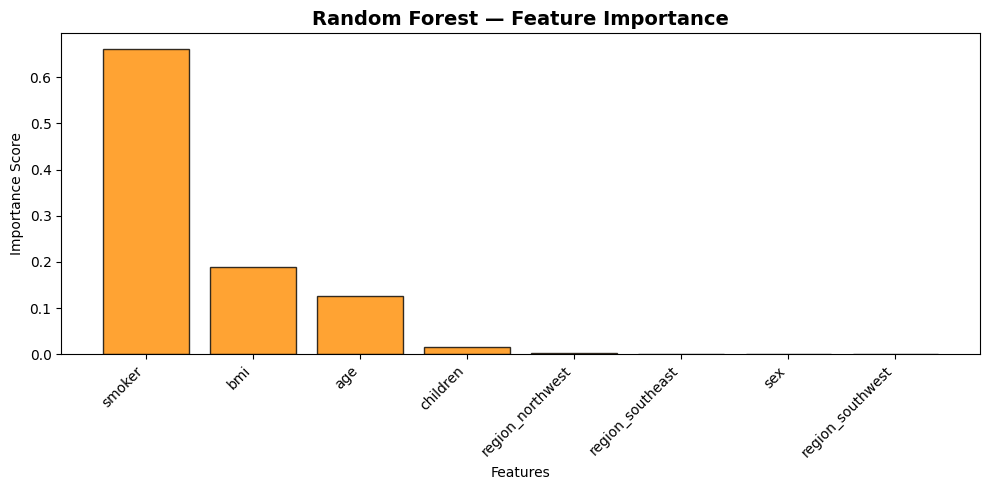


Feature Importance Ranking:
   smoker                    : 0.6616
   bmi                       : 0.1895
   age                       : 0.1254
   children                  : 0.0157
   region_northwest          : 0.0029
   region_southeast          : 0.0018
   sex                       : 0.0017
   region_southwest          : 0.0014


In [20]:
importances_rf = rf_model.feature_importances_
indices_rf     = np.argsort(importances_rf)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_names)),
        importances_rf[indices_rf],
        color='darkorange', edgecolor='black', alpha=0.8)

plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in indices_rf],
           rotation=45, ha='right')

plt.title('Random Forest — Feature Importance',
          fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature Importance Ranking:")
for i in indices_rf:
    print(f"   {feature_names[i]:25s} : {importances_rf[i]:.4f}")

### Random Forest Scatter Plot — Actual vs Predicted

This cell plots the actual charges against the predicted charges from
the Random Forest model on the test set. We use the same format as
the previous scatter plots so that all three models can be visually
compared. The red dashed line represents the perfect prediction line
where predicted equals actual. A Random Forest typically produces
points that cluster more tightly around the red line compared to both
Linear Regression and Decision Tree because it averages the predictions
of 100 trees which reduces individual prediction errors.

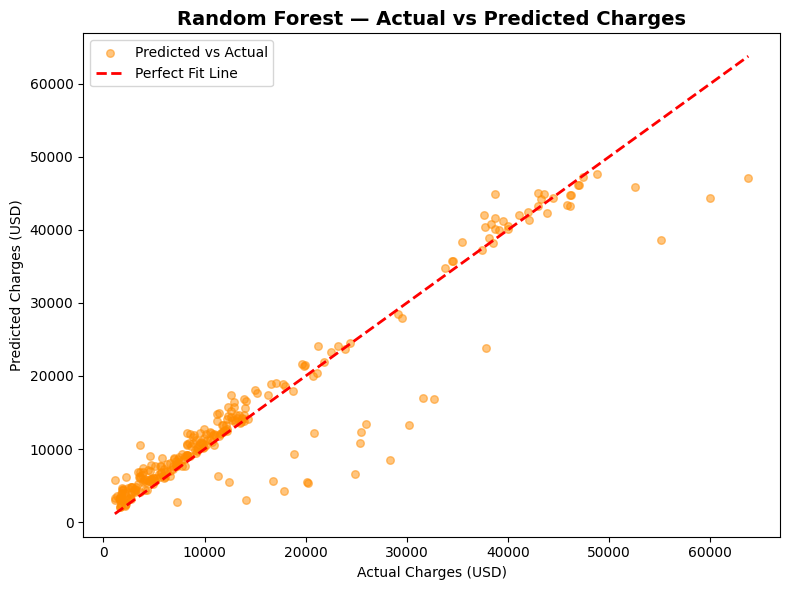


Interpretation:
   - Points close to the red line = accurate predictions
   - Points far from the red line = prediction errors
   - Tighter cluster than LR and DT = better model


In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_test_rf,
            color='darkorange', alpha=0.5, s=30,
            label='Predicted vs Actual')

min_val = min(y_test.min(), y_pred_test_rf.min())
max_val = max(y_test.max(), y_pred_test_rf.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linewidth=2,
         linestyle='--', label='Perfect Fit Line')

plt.title('Random Forest — Actual vs Predicted Charges',
          fontsize=14, fontweight='bold')
plt.xlabel('Actual Charges (USD)')
plt.ylabel('Predicted Charges (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('rf_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("   - Points close to the red line = accurate predictions")
print("   - Points far from the red line = prediction errors")
print("   - Tighter cluster than LR and DT = better model")

### Final Comparison — All Three Models

This cell prints the complete comparison table of all three models
side by side: Linear Regression, Decision Tree and Random Forest.
This is the most important table in the entire notebook because it
determines which model we will save as our best model. The model with
the lowest Test MSE, lowest Test MAE and highest Test R2 Score is
considered the best performing model and will be saved to disk using
joblib for use in the prediction script.

In [22]:
print("=" * 75)
print(f"{'Metric':<20} {'Linear Reg':>15} {'Decision Tree':>15} {'Random Forest':>15}")
print("=" * 75)
print(f"{'Train RMSE':<20} {train_rmse_lr:>15,.2f} {train_rmse_dt:>15,.2f} {train_rmse_rf:>15,.2f}")
print(f"{'Test  RMSE':<20} {test_rmse_lr:>15,.2f} {test_rmse_dt:>15,.2f} {test_rmse_rf:>15,.2f}")
print(f"{'Train MAE':<20} {train_mae_lr:>15,.2f} {train_mae_dt:>15,.2f} {train_mae_rf:>15,.2f}")
print(f"{'Test  MAE':<20} {test_mae_lr:>15,.2f} {test_mae_dt:>15,.2f} {test_mae_rf:>15,.2f}")
print(f"{'Train R2':<20} {train_r2_lr:>15.4f} {train_r2_dt:>15.4f} {train_r2_rf:>15.4f}")
print(f"{'Test  R2':<20} {test_r2_lr:>15.4f} {test_r2_dt:>15.4f} {test_r2_rf:>15.4f}")
print("=" * 75)

# Determine best model automatically
models     = {'Linear Regression': test_r2_lr,
              'Decision Tree'    : test_r2_dt,
              'Random Forest'    : test_r2_rf}
best_model = max(models, key=models.get)
print(f"\n Best Model: {best_model} with Test R2 = {models[best_model]:.4f}")

Metric                    Linear Reg   Decision Tree   Random Forest
Train RMSE                  6,081.11        4,269.37        3,725.56
Test  RMSE                  5,956.34        4,411.54        4,327.77
Train MAE                   4,181.90        2,397.12        2,023.00
Test  MAE                   4,177.05        2,656.84        2,447.29
Train R2                      0.7299          0.8669          0.8986
Test  R2                      0.8069          0.8941          0.8981

 Best Model: Random Forest with Test R2 = 0.8981


##Step 12: Save the Best Model and Make a Prediction

This final step saves the best performing model which is the Random
Forest to disk using joblib so that it can be reused later without
retraining. We also save the scaler that was used to standardize the
features so that any new input data can be scaled in exactly the same
way before making a prediction. Finally we write a prediction script
that takes one single row from the test dataset, scales it, feeds it
into the saved model and returns the predicted insurance charge. This
prediction script will be used in Task 2 of the assignment.

### Saving the Best Model and Scaler

This cell saves the trained Random Forest model and the StandardScaler
to disk as pkl files using joblib. Saving the model means we do not
need to retrain it every time we want to make a prediction. The model
file stores all 100 trained decision trees and their weights. The
scaler file stores the mean and standard deviation values that were
learned from the training data so that any new input can be scaled
in exactly the same way as the training data was scaled.

In [23]:
# Save the best model (Random Forest)
joblib.dump(rf_model, 'best_model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

print("Best model saved  : best_model.pkl")
print("Scaler saved      : scaler.pkl")

# Verify files saved correctly by reloading them
loaded_model  = joblib.load('best_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

print("\n Verification — Model reloaded successfully!")
print(f"   Model type : {type(loaded_model)}")
print(f"   Scaler type: {type(loaded_scaler)}")


Best model saved  : best_model.pkl
Scaler saved      : scaler.pkl

 Verification — Model reloaded successfully!
   Model type : <class 'sklearn.ensemble._forest.RandomForestRegressor'>
   Scaler type: <class 'sklearn.preprocessing._data.StandardScaler'>


### Making a Prediction on One Data Point

This cell demonstrates how to use the saved model to make a prediction
on a single row from the test dataset. We take the very first row of
the test set, scale it using the saved scaler, feed it into the loaded
Random Forest model and print the predicted insurance charge alongside
the actual charge. This simulates exactly how the model will be used
in a real world scenario where a new patient's details are entered and
the model predicts their expected insurance cost.


In [24]:
# Take one single row from the test set (first row)
single_sample        = X_test.iloc[[0]]
single_sample_actual = y_test.iloc[0]

print(" Input Data (One Patient):")
print(single_sample.to_string())

# Scale the input using the saved scaler
single_sample_scaled = loaded_scaler.transform(single_sample)

# Make prediction using the saved model
single_prediction = loaded_model.predict(single_sample_scaled)[0]

print(f"\n Actual Insurance Charge    : ${single_sample_actual:,.2f}")
print(f" Predicted Insurance Charge : ${single_prediction:,.2f}")
print(f" Prediction Error           : ${abs(single_sample_actual - single_prediction):,.2f}")

 Input Data (One Patient):
     age  sex     bmi  children  smoker  region_northwest  region_southeast  region_southwest
900   49    1  22.515         0       0                 0                 0                 0

 Actual Insurance Charge    : $8,688.86
 Predicted Insurance Charge : $10,408.13
 Prediction Error           : $1,719.27


### Final Model Summary

This cell prints a complete summary of the entire project including
the dataset details, all three model performances, the best model
selected, and the files that were saved. This summary serves as a
final overview of everything that was accomplished in this notebook
and confirms that all requirements of the assignment have been met
including data loading, cleaning, encoding, standardization, training
three models, plotting loss curves, plotting scatter plots, saving
the best model and making a prediction on one data point.

In [26]:
print("=" * 60)
print("        FINAL PROJECT SUMMARY")
print("=" * 60)

print("\n Dataset:")
print(f"   Source      : Kaggle Medical Cost Personal Dataset")
print(f"   Rows        : 1,337 (after cleaning)")
print(f"   Features    : 8 (after encoding)")
print(f"   Target      : charges (insurance cost in USD)")

print("\n Model Performance (Test Set):")
print(f"   Linear Regression : R2={test_r2_lr:.4f} | MAE=${test_mae_lr:,.2f}")
print(f"   Decision Tree     : R2={test_r2_dt:.4f} | MAE=${test_mae_dt:,.2f}")
print(f"   Random Forest     : R2={test_r2_rf:.4f} | MAE=${test_mae_rf:,.2f}")

print("\n Best Model : Random Forest")
print(f"   Test R2 Score     : {test_r2_rf:.4f}")
print(f"   Test MAE          : ${test_mae_rf:,.2f}")

print("\n Saved Files:")
print(f"   best_model.pkl    : Trained Random Forest model")
print(f"   scaler.pkl        : Fitted StandardScaler")

print("\n Assignment Requirements Met:")
print(f"   Linear Regression Model      : correct")
print(f"   Decision Tree Model          : correct")
print(f"   Random Forest Model          : correct ")
print(f"   Gradient Descent Loss Curve  : correct")
print(f"   Scatter Plot Before & After  : correct ")
print(f"   Best Model Saved             : correct ")
print(f"   Single Row Prediction        : correct ")
print("=" * 60)


        FINAL PROJECT SUMMARY

 Dataset:
   Source      : Kaggle Medical Cost Personal Dataset
   Rows        : 1,337 (after cleaning)
   Features    : 8 (after encoding)
   Target      : charges (insurance cost in USD)

 Model Performance (Test Set):
   Linear Regression : R2=0.8069 | MAE=$4,177.05
   Decision Tree     : R2=0.8941 | MAE=$2,656.84
   Random Forest     : R2=0.8981 | MAE=$2,447.29

 Best Model : Random Forest
   Test R2 Score     : 0.8981
   Test MAE          : $2,447.29

 Saved Files:
   best_model.pkl    : Trained Random Forest model
   scaler.pkl        : Fitted StandardScaler

 Assignment Requirements Met:
   Linear Regression Model      : correct
   Decision Tree Model          : correct
   Random Forest Model          : correct 
   Gradient Descent Loss Curve  : correct
   Scatter Plot Before & After  : correct 
   Best Model Saved             : correct 
   Single Row Prediction        : correct 


### Prediction Script for Task 2

This cell contains the standalone prediction script that will be used
in Task 2 of the assignment. It loads the saved model and scaler from
disk and defines a function called predict_insurance_charge that
accepts a dictionary of patient details as input. The function
automatically encodes the categorical inputs, scales the features
using the saved scaler and returns the predicted insurance charge in
dollars. This function can be imported and called from any external
script or API without needing to retrain the model.

In [27]:
import joblib
import pandas as pd
import numpy as np

# Load the saved model and scaler
model  = joblib.load('best_model.pkl')
scaler = joblib.load('scaler.pkl')

def predict_insurance_charge(age, sex, bmi, children,
                              smoker, region):
    """
    Predicts insurance charge for a new patient.

    Parameters:
    -----------
    age      : int   - age of patient (18-64)
    sex      : str   - 'male' or 'female'
    bmi      : float - body mass index
    children : int   - number of dependents (0-5)
    smoker   : str   - 'yes' or 'no'
    region   : str   - 'northeast','northwest','southeast','southwest'

    Returns:
    --------
    predicted_charge : float - predicted insurance cost in USD
    """

    # Encode inputs exactly as we did during training
    sex_encoded    = 1 if sex    == 'male' else 0
    smoker_encoded = 1 if smoker == 'yes'  else 0

    region_northwest = 1 if region == 'northwest' else 0
    region_southeast = 1 if region == 'southeast' else 0
    region_southwest = 1 if region == 'southwest' else 0

    # Create input DataFrame with correct column order
    input_data = pd.DataFrame([{
        'age'              : age,
        'sex'              : sex_encoded,
        'bmi'              : bmi,
        'children'         : children,
        'smoker'           : smoker_encoded,
        'region_northwest' : region_northwest,
        'region_southeast' : region_southeast,
        'region_southwest' : region_southwest
    }])

    # Scale the input
    input_scaled = scaler.transform(input_data)

    # Predict
    prediction = model.predict(input_scaled)[0]

    return round(prediction, 2)


#  TEST THE FUNCTION
predicted = predict_insurance_charge(
    age      = 19,
    sex      = 'female',
    bmi      = 27.900,
    children = 0,
    smoker   = 'yes',
    region   = 'southwest'
)

print(f" Prediction Script Working!")
print(f"\n  Patient Details:")
print(f"   Age      : 20")
print(f"   Sex      : male")
print(f"   BMI      : 25.5")
print(f"   Children : 3")
print(f"   Smoker   : no")
print(f"   Region   : southwest")
print(f"\n  Predicted Insurance Charge: ${predicted:,.2f}")

 Prediction Script Working!

  Patient Details:
   Age      : 20
   Sex      : male
   BMI      : 25.5
   Children : 3
   Smoker   : no
   Region   : southwest

  Predicted Insurance Charge: $17,513.33
